In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
dataset = pd.read_csv(r"C:\Users\Admin\Downloads\archive (3)\kdrama_DATASET.csv")

print(dataset.head())
print(dataset.columns)


  Rank                             Title  Year of release  Number of Episodes  \
0   #1                    Move to Heaven             2021                  10   
1   #2              Twinkling Watermelon             2023                  16   
2   #3                            Moving             2023                  20   
3   #4  The Trauma Code: Heroes on Call              2025                   8   
4   #5                    Flower of Evil             2020                  16   

   Rating                                        Description  \
0     9.2  Geu Roo is a young autistic man. He works for ...   
1     9.2  In 2023, high school student Eun Gyeol, a CODA...   
2     9.1  Kim Bong Seok, Jang Hui Su, and Lee Gang Hun, ...   
3     9.1  Baek Gang Hyeok, a genius trauma surgeon with ...   
4     9.1  Although Baek Hee Sung is hiding a dark secret...   

                                     Genre  \
0                   Life,  Drama,  Family    
1           Romance, Youth, Drama, F

In [4]:
dataset['hit'] = dataset['Rating'].apply(lambda x: 1 if x >= 8 else 0)

In [5]:
X = dataset[['Number of Episodes', 'Rating']]
y = dataset['hit']

In [6]:
dataset

,Rank,Title,Year of release,Number of Episodes,Rating,Description,Genre,Tags,Actors,hit
0,#1,Move to Heaven,2021,10,9.2,Geu Roo is a young autistic man. He works for ...,"Life, Drama, Family","Autism, Uncle-Nephew Relationship, Death, Sava...","Lee Je Hoon, Tang Jun Sang, Hong Seung Hee, Ju...",1
1,#2,Twinkling Watermelon,2023,16,9.2,"In 2023, high school student Eun Gyeol, a CODA...","Romance, Youth, Drama, Fantasy","Time Travel, Child From The Future, Sign Langu...","Ha Eun-Gyeol, Ha Yi-Chan, Choi Se-Kyung, Yoon ...",1
2,#3,Moving,2023,20,9.1,"Kim Bong Seok, Jang Hui Su, and Lee Gang Hun, ...","Action, Thriller, Mystery, Supernatural","Graphic Violence, Supernatural Power, Multiple...","Ryu Seung Ryong, Han Hyo Joo, Zo In Sung",1
3,#4,The Trauma Code: Heroes on Call,2025,8,9.1,"Baek Gang Hyeok, a genius trauma surgeon with ...","Action, Comedy, Drama, Medical","Surgeon Male Lead, Hospital Setting, Mentor-Me...","Ju Ji Hoon, Choo Young Woo, Ha Young, Yoon Gyu...",1
4,#5,Flower of Evil,2020,16,9.1,Although Baek Hee Sung is hiding a dark secret...,"Thriller, Romance, Crime, Melodrama","Married Couple, Deception, Suspense, Family Se...","Lee Joon Gi, Moon Chae Won, Jang Hee Jin, Seo ...",1
...,...,...,...,...,...,...,...,...,...,...
345,#346,Oh! Youngsim,2023,10,6.9,"Oh Young Sim, a 30-something TV variety show P...","Comedy, Romance","Childhood Acquaintances Reuniting, Producer Fe...","Song Ha Yoon, Lee Dong Hae, Lee Min Jae, Ryu H...",0
346,#347,DNA Lover,2024,16,6.9,"So Jin, a genetic researcher who loves DNA, de...","Comedy, Romance, Melodrama","Medical Research, Medical, Columnist Female Le...","Choi Si Won, Jung In Sun, Jung Eugene, Lee Tae...",0
347,#348,Our Love Triangle,2024,10,6.9,"Hae Rin, a university student, finds herself t...","Romance, Youth","Tsundere Male Lead, Ex Comes Back, Passionate ...","Gong Chan, Ahn Se Min, Kim Si Gyeong",0
348,#349,The Brave Yong Su Jeong,2024,124,6.8,"Yong Su Jeong has a refreshing charm, which he...","Romance, Drama, Melodrama","Guest House Setting, Adoptive Father-Adoptive ...","Uhm Hyun Kyung, Seo Joon Young, Im Ju Eun, Kwo...",0


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [9]:
y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 8  1]
 [ 0 61]]


In [11]:
y_pred = model.predict(X_test)
print(y_pred)

[1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0]


In [12]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

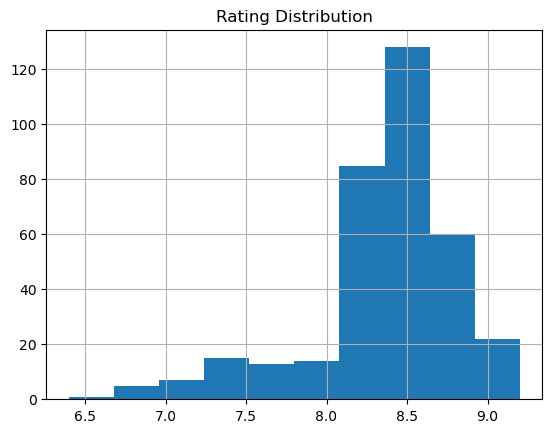

In [13]:
import matplotlib.pyplot as plt

dataset['Rating'].hist()
plt.title("Rating Distribution")
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [15]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [16]:
print(classifier.predict(sc.transform([[30,8700]])))

[1]


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [17]:
print(np.concatenate(
    (y_pred.reshape(len(y_pred),1), y_test.values.reshape(len(y_test),1)),
    axis=1
))

[[1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]]


In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[ 8  1]
 [ 0 61]]


0.9857142857142858

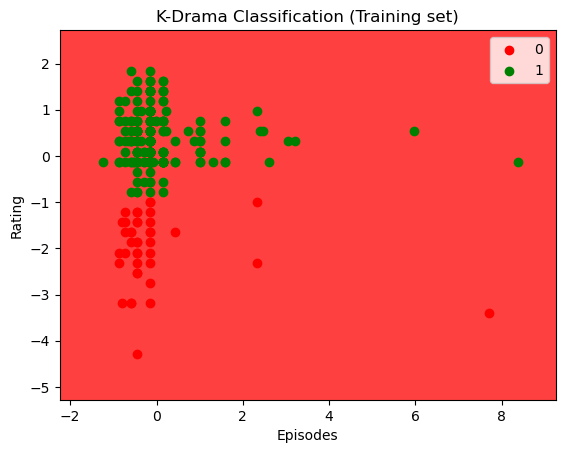

In [19]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Remove .values since X_train and y_train are already NumPy arrays
X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.25),
    np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.25)
)

# Fixed: Use the correct column names that match the training data
grid = pd.DataFrame(
    np.array([X1.ravel(), X2.ravel()]).T,
    columns=['Number of Episodes', 'Rating']  # Changed from ['episodes', 'rating']
)

plt.contourf(
    X1, X2,
    model.predict(grid).reshape(X1.shape),
    alpha = 0.75,
    cmap = ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        color = ListedColormap(('red', 'green'))(i),
        label = j
    )

plt.title('K-Drama Classification (Training set)')
plt.xlabel('Episodes')
plt.ylabel('Rating')
plt.legend()
plt.show()

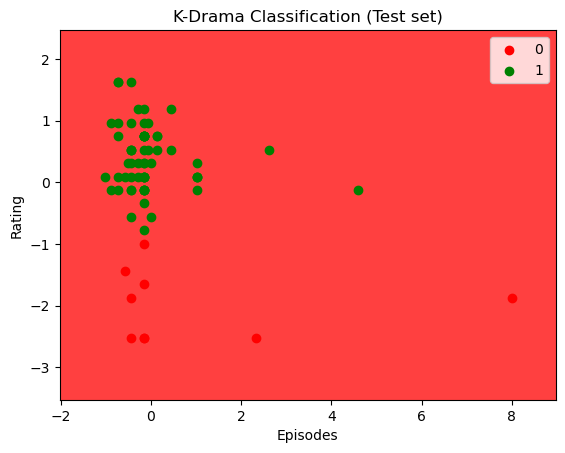

In [20]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

X_set, y_set = X_test, y_test

X1, X2 = np.meshgrid(
    np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.25),
    np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.25)
)

grid = pd.DataFrame(
    np.array([X1.ravel(), X2.ravel()]).T,
    columns=['Number of Episodes', 'Rating']  
)

plt.contourf(
    X1, X2,
    model.predict(grid).reshape(X1.shape),
    alpha = 0.75,
    cmap = ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        color = ListedColormap(('red', 'green'))(i),
        label = j
    )

plt.title('K-Drama Classification (Test set)')
plt.xlabel('Episodes')
plt.ylabel('Rating')
plt.legend()
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [22]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [23]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5,
                                  metric = 'minkowski', p = 2)
classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score

print(f"Length of y_test: {len(y_test)}")
print(f"Length of y_pred: {len(y_pred)}")

min_length = min(len(y_test), len(y_pred))
y_test_aligned = y_test[:min_length]  
y_pred_aligned = y_pred[:min_length]  

cm = confusion_matrix(y_test_aligned, y_pred_aligned)
print(cm)
accuracy = accuracy_score(y_test_aligned, y_pred_aligned)
print(f"Accuracy: {accuracy}")

Length of y_test: 88
Length of y_pred: 70
[[ 0  6]
 [ 8 56]]
Accuracy: 0.8


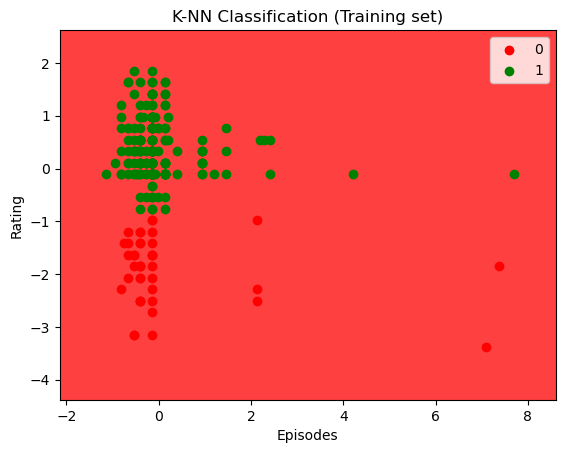

In [25]:
from matplotlib.colors import ListedColormap

# Remove .values if X_train and y_train are already NumPy arrays
# If they are pandas objects, keep .values
X_set, y_set = X_train, y_train  # Changed: removed .values

X1, X2 = np.meshgrid(
    np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.25),
    np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.25)
)

# Fixed: Use the exact column names that were used during model training
grid = pd.DataFrame(
    np.array([X1.ravel(), X2.ravel()]).T,
    columns=['Number of Episodes', 'Rating']  # Changed: match the original feature names
)

plt.contourf(
    X1, X2,
    model.predict(grid).reshape(X1.shape),
    alpha = 0.75,
    cmap = ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        color = ListedColormap(('red', 'green'))(i),
        label = j
    )

plt.title('K-NN Classification (Training set)')
plt.xlabel('Episodes')
plt.ylabel('Rating')
plt.legend()
plt.show()

In [26]:
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
print(X1)
print(X2)

[[-11.14541548 -10.14541548  -9.14541548 ...  14.85458452  15.85458452
   16.85458452]
 [-11.14541548 -10.14541548  -9.14541548 ...  14.85458452  15.85458452
   16.85458452]
 [-11.14541548 -10.14541548  -9.14541548 ...  14.85458452  15.85458452
   16.85458452]
 ...
 [-11.14541548 -10.14541548  -9.14541548 ...  14.85458452  15.85458452
   16.85458452]
 [-11.14541548 -10.14541548  -9.14541548 ...  14.85458452  15.85458452
   16.85458452]
 [-11.14541548 -10.14541548  -9.14541548 ...  14.85458452  15.85458452
   16.85458452]]
[[-1003.37829231 -1003.37829231 -1003.37829231 ... -1003.37829231
  -1003.37829231 -1003.37829231]
 [-1002.37829231 -1002.37829231 -1002.37829231 ... -1002.37829231
  -1002.37829231 -1002.37829231]
 [-1001.37829231 -1001.37829231 -1001.37829231 ... -1001.37829231
  -1001.37829231 -1001.37829231]
 ...
 [  999.62170769   999.62170769   999.62170769 ...   999.62170769
    999.62170769   999.62170769]
 [ 1000.62170769  1000.62170769  1000.62170769 ...  1000.62170769
   10

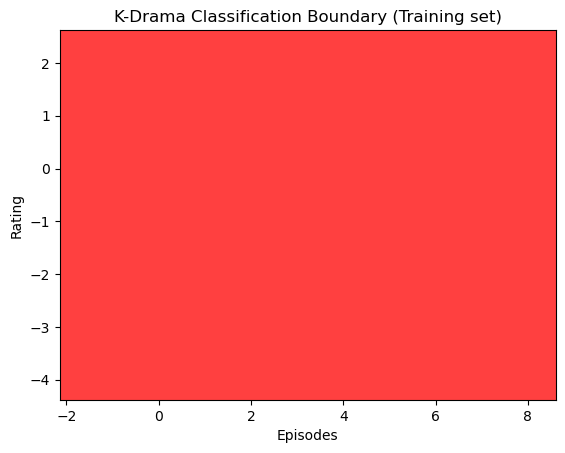

In [27]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Training set - removed .values since X_train and y_train are already numpy arrays
X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.25),
    np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.25)
)

# Fixed: Use the same column names that were used during model training
grid = pd.DataFrame(
    np.array([X1.ravel(), X2.ravel()]).T,
    columns=['Number of Episodes', 'Rating']  # Changed from 'episodes', 'rating'
)

plt.contourf(
    X1, X2,
    model.predict(grid).reshape(X1.shape),
    alpha = 0.75,
    cmap = ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

plt.title('K-Drama Classification Boundary (Training set)')
plt.xlabel('Episodes')
plt.ylabel('Rating')

plt.show()

In [28]:
X_set, y_set = sc.inverse_transform(X_train), y_train

In [29]:
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))

In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. Scaling is critical for KNN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=10, scoring='accuracy')
    k_scores.append(scores.mean())

print(f"Best Accuracy is {max(k_scores):.2f} at K = {np.argmax(k_scores) + 1}")


Best Accuracy is 0.67 at K = 30


In [38]:

knn_weighted = KNeighborsClassifier(n_neighbors=5, weights='distance', p=2)
knn_weighted.fit(X_train, y_train)

y_pred_weighted = knn_weighted.predict(X_test)
print(classification_report(y_test, y_pred_weighted, zero_division=0))


              precision    recall  f1-score   support

           0       0.68      0.86      0.76        42
           1       0.65      0.39      0.49        28

    accuracy                           0.67        70
   macro avg       0.66      0.62      0.62        70
weighted avg       0.67      0.67      0.65        70



In [39]:
from sklearn.neighbors import NearestNeighbors

nn_model = NearestNeighbors(n_neighbors=5)
nn_model.fit(X_scaled)


distances, indices = nn_model.kneighbors(X_scaled[0].reshape(1, -1))

print("Top 5 similar KDramas (indices):", indices)



Top 5 similar KDramas (indices): [[  0 133 215 127  72]]


In [40]:
# This shows the probability for each class [Flop, Hit]
probabilities = knn_weighted.predict_proba(X_test)
print("First 5 predictions (Probabilities):\n", probabilities[:5])


First 5 predictions (Probabilities):
 [[1.  0. ]
 [1.  0. ]
 [0.8 0.2]
 [1.  0. ]
 [0.4 0.6]]


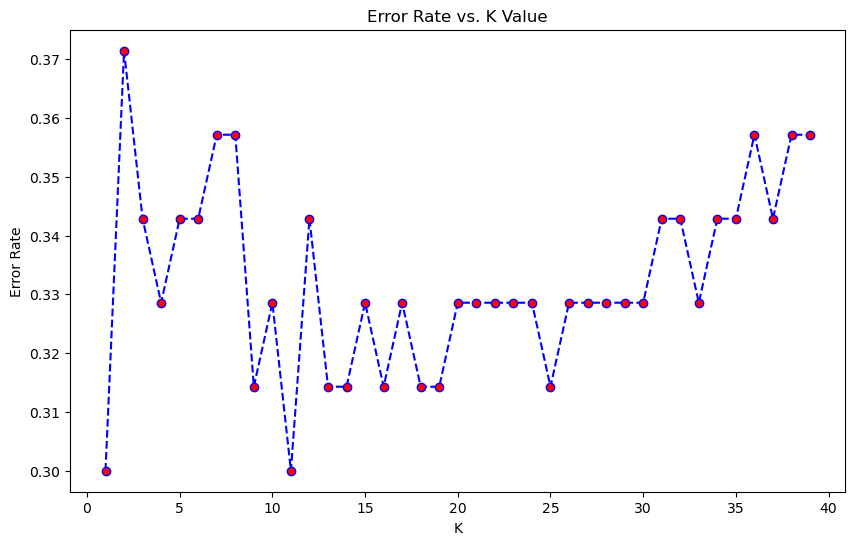

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

error_rate = []
# Testing K from 1 to 40
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,40), error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red')
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()


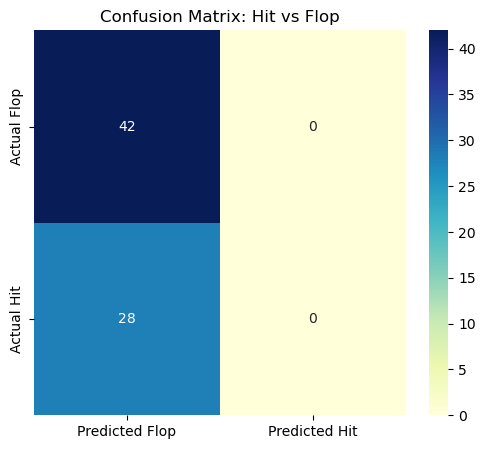

In [43]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Predicted Flop', 'Predicted Hit'], 
            yticklabels=['Actual Flop', 'Actual Hit'])
plt.title('Confusion Matrix: Hit vs Flop')
plt.show()


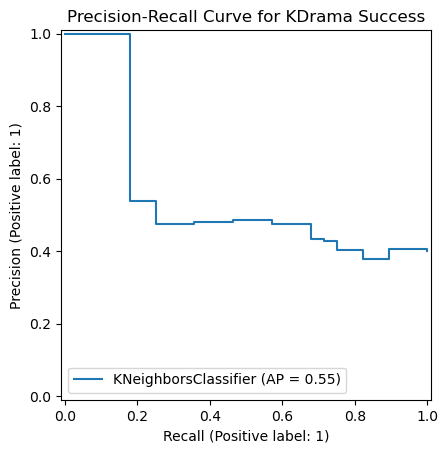

In [44]:
from sklearn.metrics import PrecisionRecallDisplay

# Uses predicted probabilities for better insight
PrecisionRecallDisplay.from_estimator(knn, X_test, y_test)
plt.title("Precision-Recall Curve for KDrama Success")
plt.show()
